In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv("../data/master.csv")
master['date'] = pd.to_datetime(master['date'])

print(f"Shape: {master.shape}")
print(f"Date range: {master['date'].min()} to {master['date'].max()}")
print(f"States: {master['state'].nunique()}")
print(master.head(3))

Shape: (3741, 13)
Date range: 2015-01-01 00:00:00 to 2024-08-01 00:00:00
States: 34
                         state       date  rice_price  oil_price   dal_price  \
0  Andaman And Nicobar Islands 2015-01-01       40.03        NaN  114.849091   
1  Andaman And Nicobar Islands 2015-02-01       36.00        NaN   90.750000   
2  Andaman And Nicobar Islands 2015-03-01       36.00        NaN   96.470588   

   wheat_price  year  rainfall_mm  yield_ton_per_hectare  production_tonnes  \
0       34.375  2015          NaN               6.762393            16383.0   
1       27.000  2015          NaN               6.762393            16383.0   
2       27.000  2015          NaN               6.762393            16383.0   

   stunting_rate  underweight_rate  anaemia_rate  
0           22.5              23.7          40.0  
1           22.5              23.7          40.0  
2           22.5              23.7          40.0  


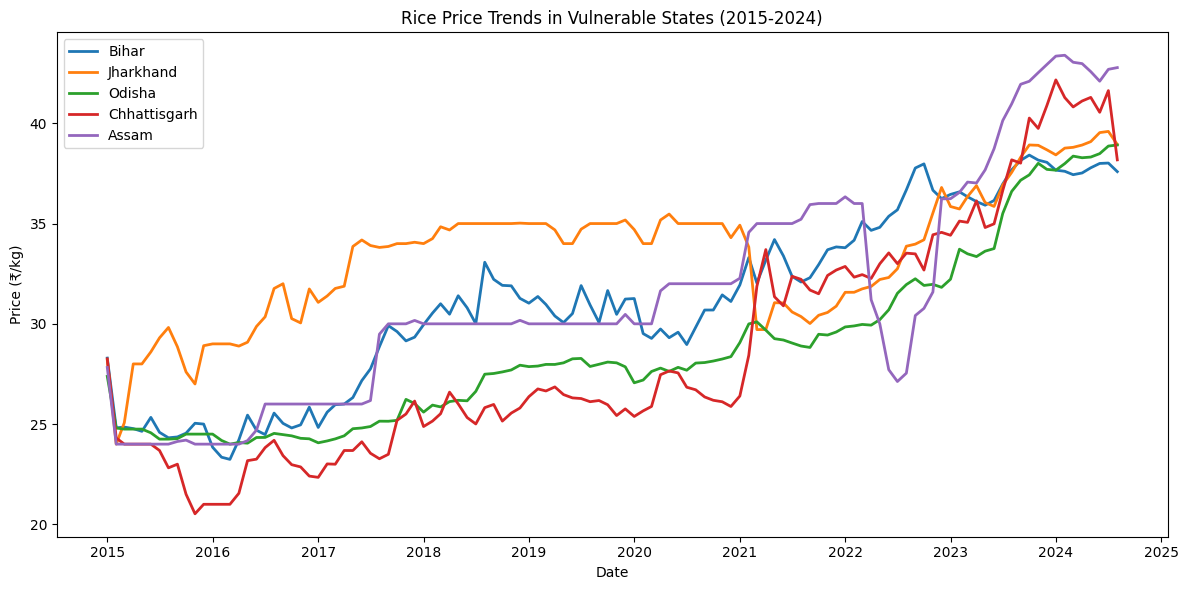

Chart 1 Saved


In [ ]:
vulnerable  =  ['Bihar', 'Jharkhand', 'Odisha','Chhattisgarh','Assam']

fig, ax = plt.subplots(figsize=(12, 6))
for state in vulnerable:
    df_state = master[master['state'] == state]
    ax.plot(df_state['date'], df_state['rice_price'], label=state, linewidth=2 )

ax.set_title("Rice Price Trends in Vulnerable States (2015-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹/kg)")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/01_food_price_trends.png", dpi = 150)
plt.show()
print("Chart 1 Saved")

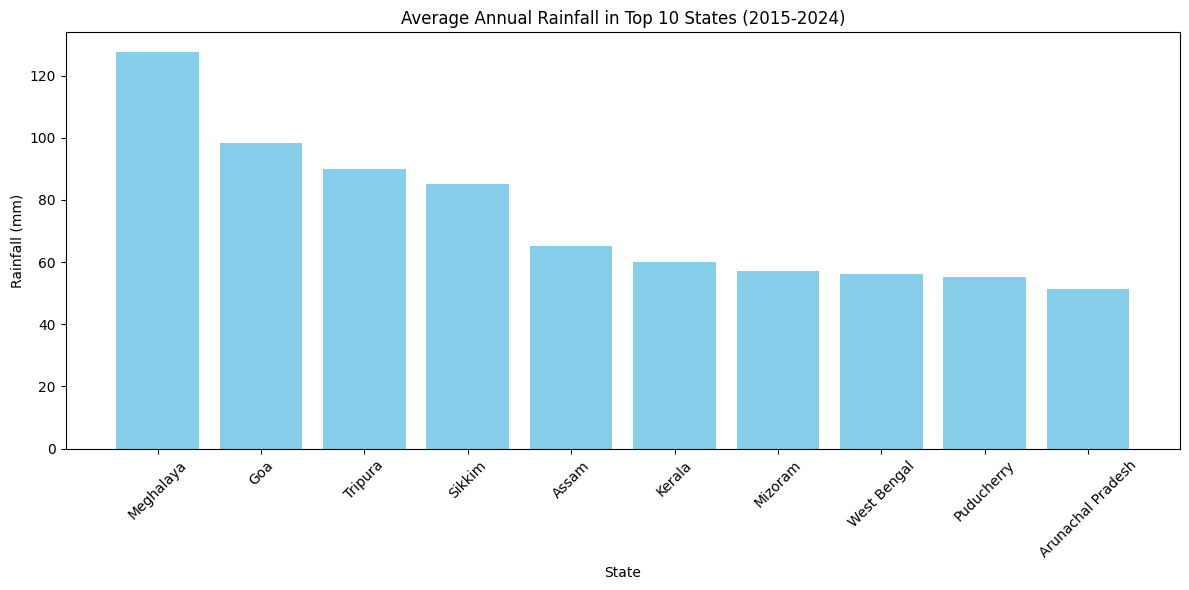

Chart 2 Saved


In [ ]:
rain_annual = master.groupby(['state', 'year'])['rainfall_mm'].sum().reset_index()
rain_avg = rain_annual.groupby('state')['rainfall_mm'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(rain_avg.index, rain_avg.values, color='skyblue')
ax.set_title("Average Annual Rainfall in Top 10 States (2015-2024)")
ax.set_xlabel("State")     
ax.set_ylabel("Rainfall (mm)")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("../charts/02_avg_annual_rainfall.png", dpi = 150)
plt.show()
print("Chart 2 Saved")

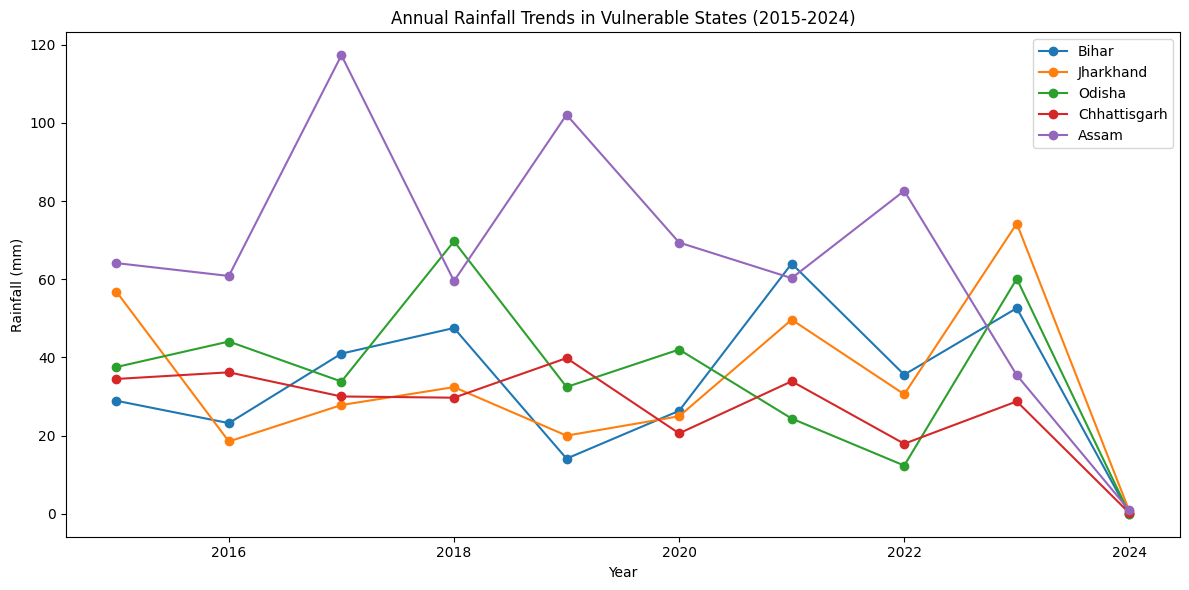

Chart 3 Saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for state in vulnerable:
    df_state = master[master['state'] == state].groupby('year')['rainfall_mm'].sum().reset_index()
    ax.plot(df_state['year'], df_state['rainfall_mm'], label=state, marker='o')

ax.set_title("Annual Rainfall Trends in Vulnerable States (2015-2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/03_annual_rainfall_trends.png", dpi = 150)
plt.show()
print("Chart 3 Saved")

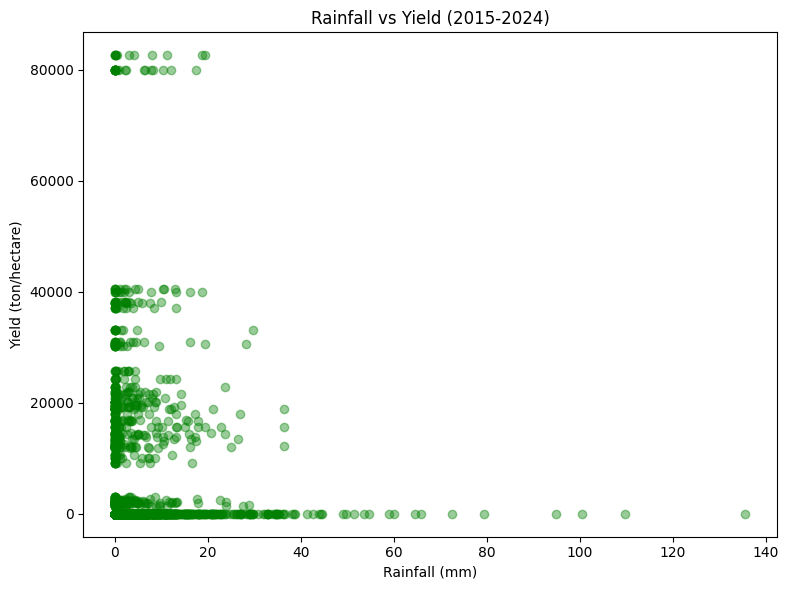

Chart 4 Saved


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(master['rainfall_mm'], master['yield_ton_per_hectare'], alpha=0.4, color='green')
ax.set_title("Rainfall vs Yield (2015-2024)")
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Yield (ton/hectare)")
plt.tight_layout()
plt.savefig("../charts/04_rainfall_vs_yield.png", dpi = 150)
plt.show()
print("Chart 4 Saved")

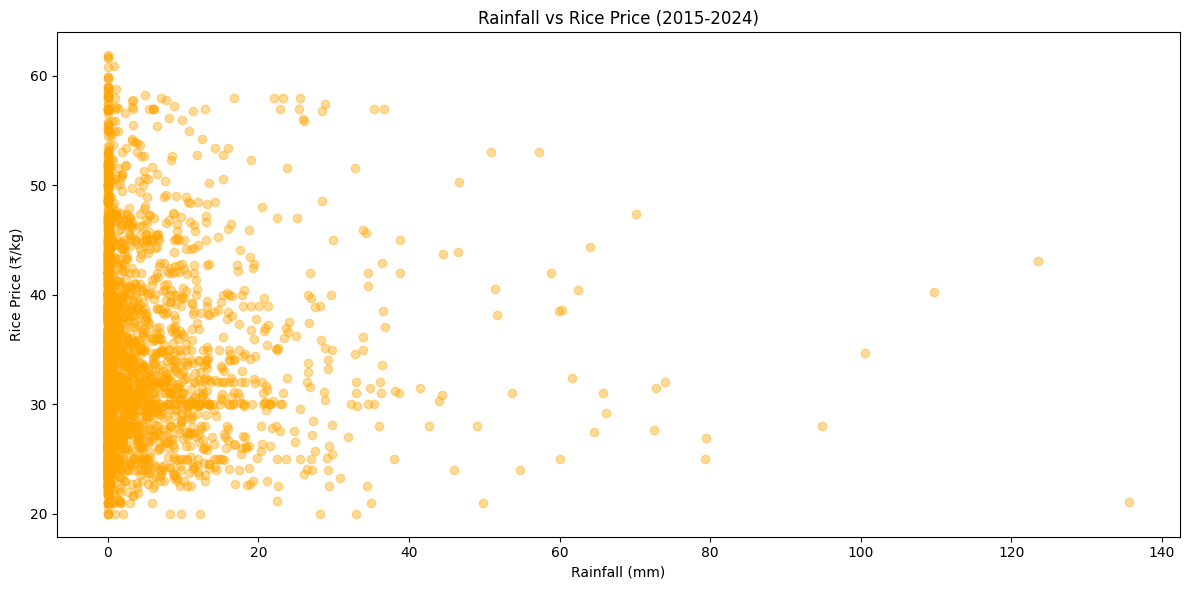

Chart 5 Saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(master['rainfall_mm'], master['rice_price'], alpha=0.4, color='orange')
ax.set_title("Rainfall vs Rice Price (2015-2024)")
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Rice Price (₹/kg)")
plt.tight_layout()
plt.savefig("../charts/05_rainfall_vs_price.png", dpi = 150)
plt.show()
print("Chart 5 Saved")

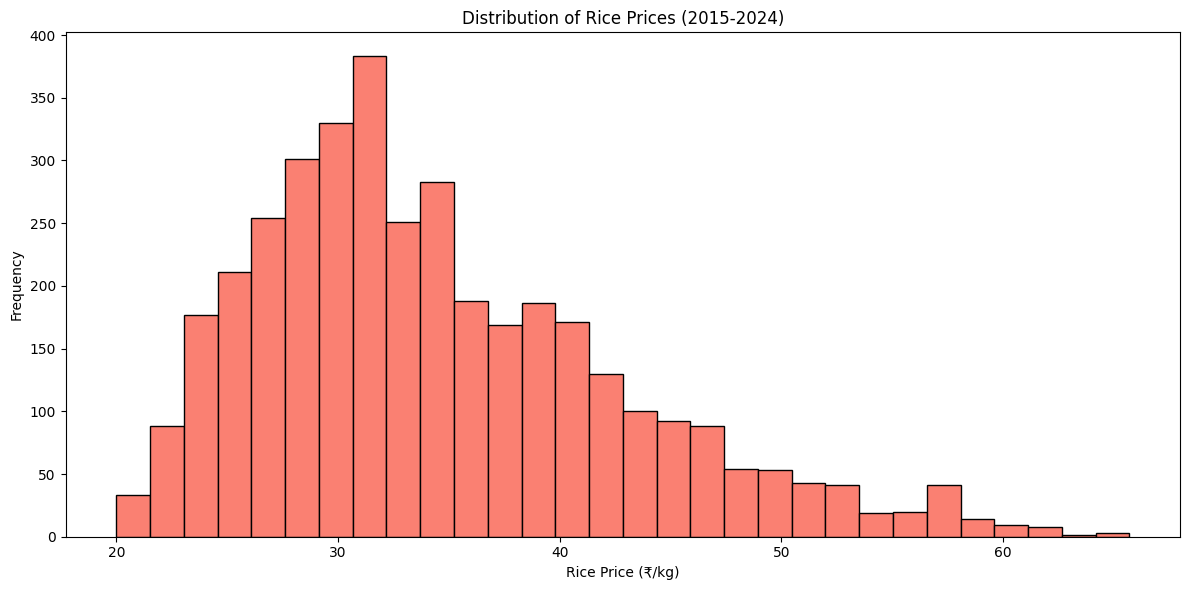

Chart 6 Saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(master['rice_price'].dropna(), bins=30, color='salmon', edgecolor='black')
ax.set_title("Distribution of Rice Prices (2015-2024)")
ax.set_xlabel("Rice Price (₹/kg)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("../charts/06_rice_price_distribution.png", dpi = 150)
plt.show()
print("Chart 6 Saved")

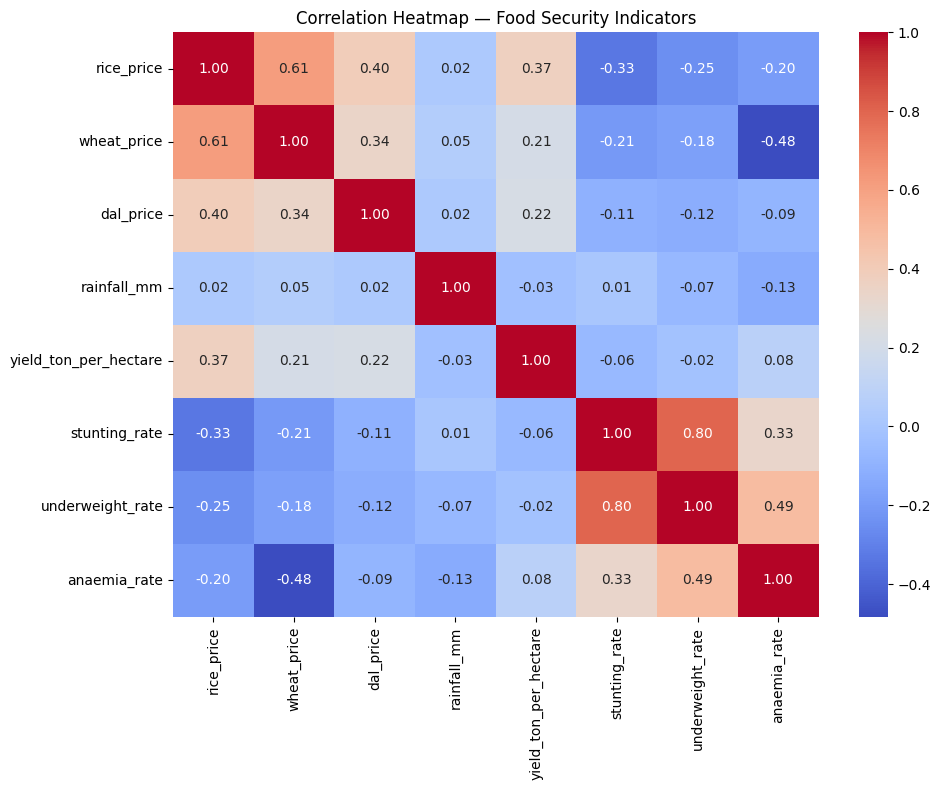

Chart 7 Saved


In [ ]:
cols = ['rice_price', 'wheat_price', 'dal_price','rainfall_mm',
         'yield_ton_per_hectare', 'stunting_rate', 'underweight_rate', 'anaemia_rate']
corr = master[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title("Correlation Heatmap — Food Security Indicators")
plt.tight_layout()
plt.savefig("../charts/07_correlation_heatmap.png", dpi = 150)
plt.show()
print("Chart 7 Saved")

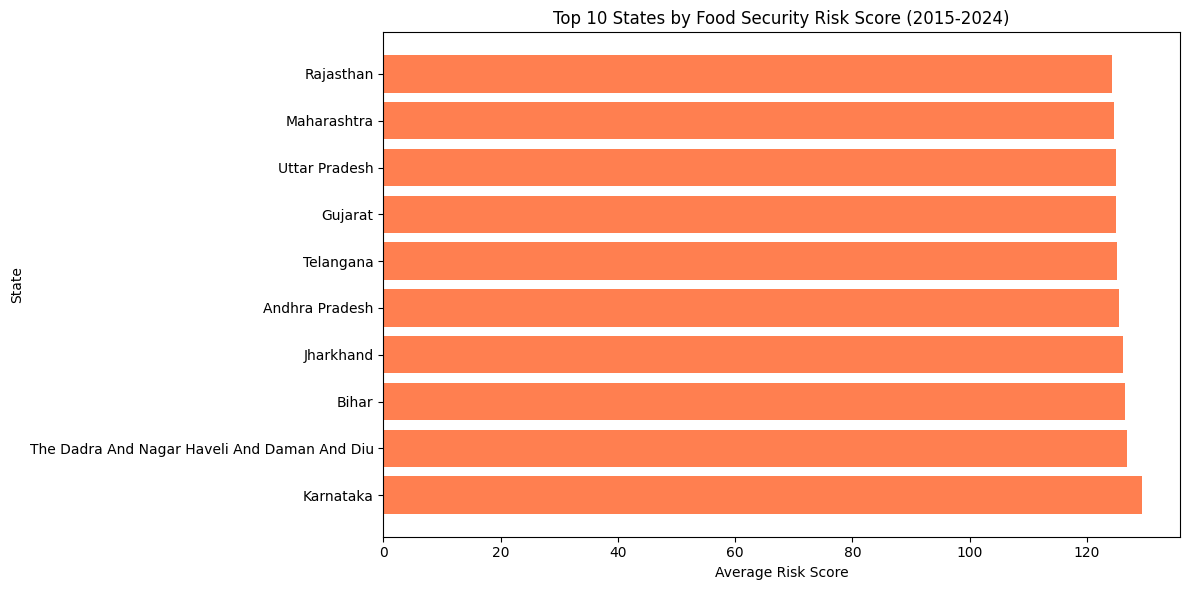

Chart 8 Saved


In [ ]:
master['risk_score'] = (
    master['rice_price'].fillna(master['rice_price'].mean()) * 0.4 +
    master['stunting_rate'].fillna(master['stunting_rate'].mean()) * 0.4 +
    (100 - master['rainfall_mm'].fillna(master['rainfall_mm'].mean()).clip(0, 100))
)

risk_ranking = master.groupby('state')['risk_score'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(risk_ranking.index, risk_ranking.values, color='coral')
ax.set_title("Top 10 States by Food Security Risk Score (2015-2024)")
ax.set_xlabel("Average Risk Score")
ax.set_ylabel("State")
plt.tight_layout()
plt.savefig("../charts/08_food_security_risk_ranking.png", dpi = 150)
plt.show()
print("Chart 8 Saved")